<a href="https://colab.research.google.com/github/psarya/Mental_Health_Classifier/blob/main/Mental_Health_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Mental Health Status Classification
**Social Media Text → Depression / Anxiety / Suicidal / Normal**

**TF-IDF + SVM + Logistic Regression + BERT (optional GPU)**

> Run cells in order. Upload your 3 CSV files to `/content/` first.

## Cell 1 — Install dependencies

In [5]:
# %%capture
!pip install streamlit scikit-learn pandas numpy matplotlib seaborn \
#             wordcloud textblob nltk pyngrok transformers torch \
#             imbalanced-learn shap

## Cell 2 — Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import re
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score,
                              roc_auc_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer

print(" All imports successful")

 All imports successful


## Cell 3 — Stage 1 — Problem Definition

In [7]:
# PROBLEM STATEMENT
# -----------------
# Classify Reddit / Twitter posts into 4 mental health categories:
#   • Anxiety    — excessive worry, panic attacks, restlessness
#   • Depression — sadness, hopelessness, anhedonia, low energy
#   • Suicidal   — suicidal ideation, self-harm expressions
#   • Normal     — everyday content with no mental health markers
#
# Approach:
#   • Baseline  : TF-IDF bigrams + SVM / Logistic Regression
#   • Advanced  : BERT fine-tuning (requires GPU)
#   • Ethics    : Privacy, consent, stigma, dual-use risk addressed
#
# Evaluation metrics:
#   • Accuracy, F1-macro (handles class imbalance)
#   • Sensitivity (recall) and Specificity per class
#     — Critical for clinical screening: high sensitivity = fewer missed cases
print("Stage 1 — Problem defined ")

Stage 1 — Problem defined 


## Cell 4 — Stage 2 — Data Loading & Understanding

In [8]:
# Upload your CSV files to /content/ in Colab before running this cell.

train_raw = pd.read_csv("/content/mental_heath_unbanlanced.csv")
feat_df   = pd.read_csv("/content/mental_heath_feature_engineered.csv")
test_df   = pd.read_csv("/content/mental_health_combined_test.csv")

print("── TRAIN (raw) ─────────────────────────────────────────")
print(f"Shape: {train_raw.shape}")
print("Class distribution:")
print(train_raw['status'].value_counts())

print("\n── TEST ────────────────────────────────────────────────")
print(f"Shape: {test_df.shape}")
print("Class distribution (balanced):")
print(test_df['status'].value_counts())

print("\n── FEATURE-ENGINEERED ──────────────────────────────────")
print(f"Shape: {feat_df.shape}")
print(f"Columns: {feat_df.columns.tolist()}")

print("\n── TEXT LENGTH STATS ───────────────────────────────────")
print(train_raw['text'].dropna().str.len().describe())

── TRAIN (raw) ─────────────────────────────────────────
Shape: (49612, 3)
Class distribution:
status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

── TEST ────────────────────────────────────────────────
Shape: (992, 2)
Class distribution (balanced):
status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64

── FEATURE-ENGINEERED ──────────────────────────────────
Shape: (49612, 21)
Columns: ['Unique_ID', 'text', 'status', 'text_length', 'word_count', 'num_urls', 'num_emojis', 'num_special_chars', 'num_excess_punct', 'avg_word_length', 'stopword_ratio', 'type_token_ratio', 'polarity', 'subjectivity', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword']

── TEXT LENGTH STATS ───────────────────────────────────
count    49612.000000
mean       399.227143
std        617.780591
min          7.000000
25%         74.00

## Cell 5 — Stage 3 — Data Preprocessing & Cleaning

In [9]:
# FIX: keyword columns had inconsistent values ('1', 'True', 'False')
# FIX: NaN text rows handled explicitly
# FIX: lemmatization added for better generalisation

STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

MENTAL_HEALTH_STOPWORDS = {
    'feel', 'like', 'im', 'ive', 'dont', 'cant', 'just',
    'get', 'really', 'know', 'think', 'time', 'one', 'day',
    'want', 'make', 'go', 'going', 'got', 'even', 'way',
}

def clean_text(text):
    """Full NLP cleaning pipeline matching production preprocessing."""
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)               # mentions/hashtags
    text = re.sub(r'\d+', '', text)                     # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep letters only
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS
              and t not in MENTAL_HEALTH_STOPWORDS
              and len(t) > 2]
    return ' '.join(tokens)

# FIX: fix keyword columns with inconsistent True/1/False encoding
def fix_bool_col(series):
    return series.map(lambda x: 1 if str(x) in ('1','True','true') else 0)

for col in ['has_suicidal_keyword','has_stress_keyword','has_help_keyword']:
    if col in feat_df.columns:
        feat_df[col] = fix_bool_col(feat_df[col])

print("Cleaning text (this takes ~1 min)...")
train_raw['clean_text'] = train_raw['text'].apply(clean_text)
test_df['clean_text']   = test_df['text'].apply(clean_text)

# Remove empty texts after cleaning
train_raw = train_raw[train_raw['clean_text'].str.len() > 5].copy()
test_df   = test_df[test_df['clean_text'].str.len() > 5].copy()
train_raw.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(f"Train after cleaning: {train_raw.shape}")
print(f"Test  after cleaning: {test_df.shape}")
print("\nSample cleaned texts:")
for cls in train_raw['status'].unique():
    ex = train_raw[train_raw['status']==cls]['clean_text'].iloc[0]
    print(f"  [{cls}]: {ex[:120]}")

Cleaning text (this takes ~1 min)...
Train after cleaning: (48522, 4)
Test  after cleaning: (992, 3)

Sample cleaned texts:
  [Anxiety]: trouble sleeping confused mind restless heart tune
  [Normal]: dreaming crush game god
  [Depression]: recently went breakup said still want friend said try talk thing always hurt lose feeling pain stop hurt much cannot cry
  [Suicidal]: year old good friend tired problem bullying little hit hard thing annoys friend succeeding life without trying relations


## Cell 6 — Stage 4 — Exploratory Data Analysis

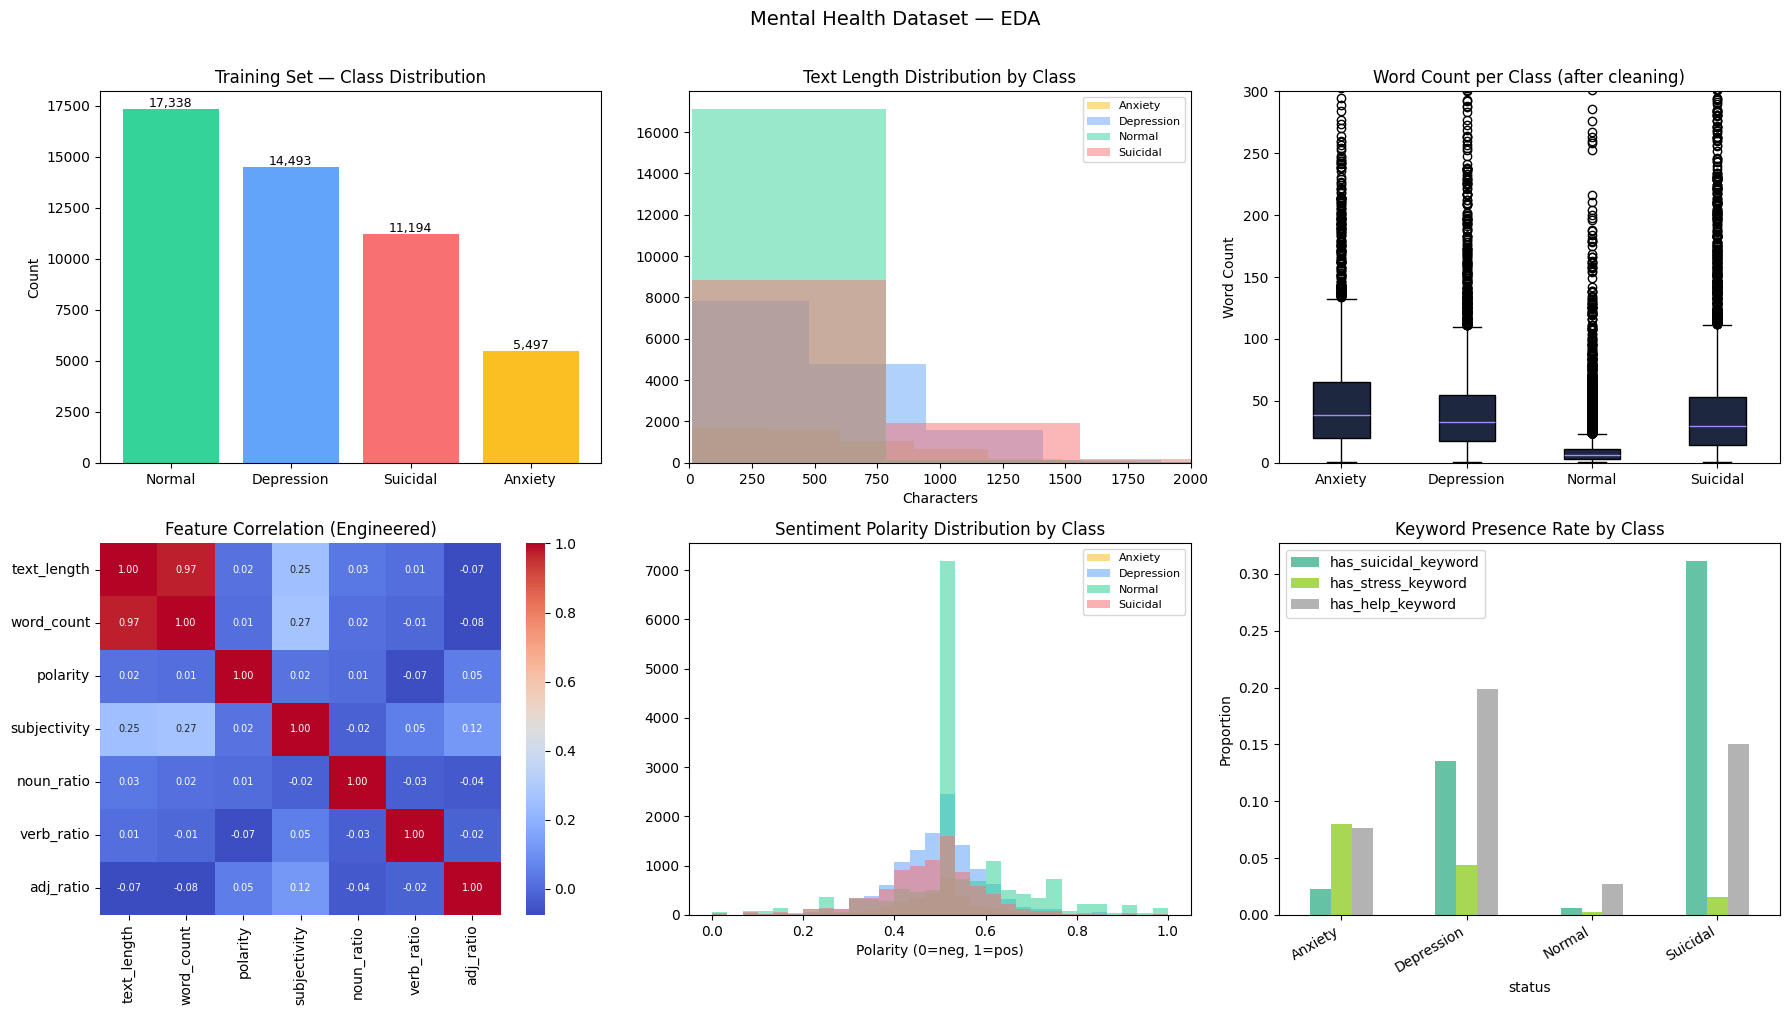

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class distribution (train)
CLASS_COLORS = {'Anxiety':'#fbbf24','Depression':'#60a5fa',
                'Normal':'#34d399','Suicidal':'#f87171'}
counts = train_raw['status'].value_counts()
axes[0,0].bar(counts.index, counts.values,
              color=[CLASS_COLORS.get(c,'#888') for c in counts.index])
axes[0,0].set_title("Training Set — Class Distribution")
axes[0,0].set_ylabel("Count")
for i,(k,v) in enumerate(counts.items()):
    axes[0,0].text(i, v+100, f'{v:,}', ha='center', fontsize=9)

# 2. Text length distribution per class
for cls, color in CLASS_COLORS.items():
    subset = train_raw[train_raw['status']==cls]['text'].str.len()
    axes[0,1].hist(subset, bins=50, alpha=0.5, label=cls, color=color)
axes[0,1].set_title("Text Length Distribution by Class")
axes[0,1].set_xlabel("Characters")
axes[0,1].legend(fontsize=8)
axes[0,1].set_xlim(0, 2000)

# 3. Word count per class
train_raw['word_count_clean'] = train_raw['clean_text'].str.split().str.len()
bp_data = [train_raw[train_raw['status']==c]['word_count_clean'].values
           for c in CLASS_COLORS]
axes[0,2].boxplot(bp_data, labels=list(CLASS_COLORS.keys()),
                  patch_artist=True,
                  boxprops=dict(facecolor='#1e2740'),
                  medianprops=dict(color='#a78bfa'))
axes[0,2].set_title("Word Count per Class (after cleaning)")
axes[0,2].set_ylabel("Word Count")
axes[0,2].set_ylim(0, 300)

# 4. Feature correlation heatmap (engineered features)
num_cols = ['text_length','word_count','polarity','subjectivity',
            'noun_ratio','verb_ratio','adj_ratio']
corr_data = feat_df[num_cols].dropna().head(5000).corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,0], annot_kws={'size':7})
axes[1,0].set_title("Feature Correlation (Engineered)")

# 5. Polarity by class
for cls, color in CLASS_COLORS.items():
    subset = feat_df[feat_df['status']==cls]['polarity'].dropna()
    axes[1,1].hist(subset, bins=30, alpha=0.55, label=cls, color=color)
axes[1,1].set_title("Sentiment Polarity Distribution by Class")
axes[1,1].set_xlabel("Polarity (0=neg, 1=pos)")
axes[1,1].legend(fontsize=8)

# 6. Keyword presence
kw_cols = ['has_suicidal_keyword','has_stress_keyword','has_help_keyword']
kw_means = feat_df.groupby('status')[kw_cols].mean()
kw_means.plot(kind='bar', ax=axes[1,2], colormap='Set2')
axes[1,2].set_title("Keyword Presence Rate by Class")
axes[1,2].set_ylabel("Proportion")
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=30, ha='right')

plt.suptitle("Mental Health Dataset — EDA", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Cell 7 — Word clouds per class

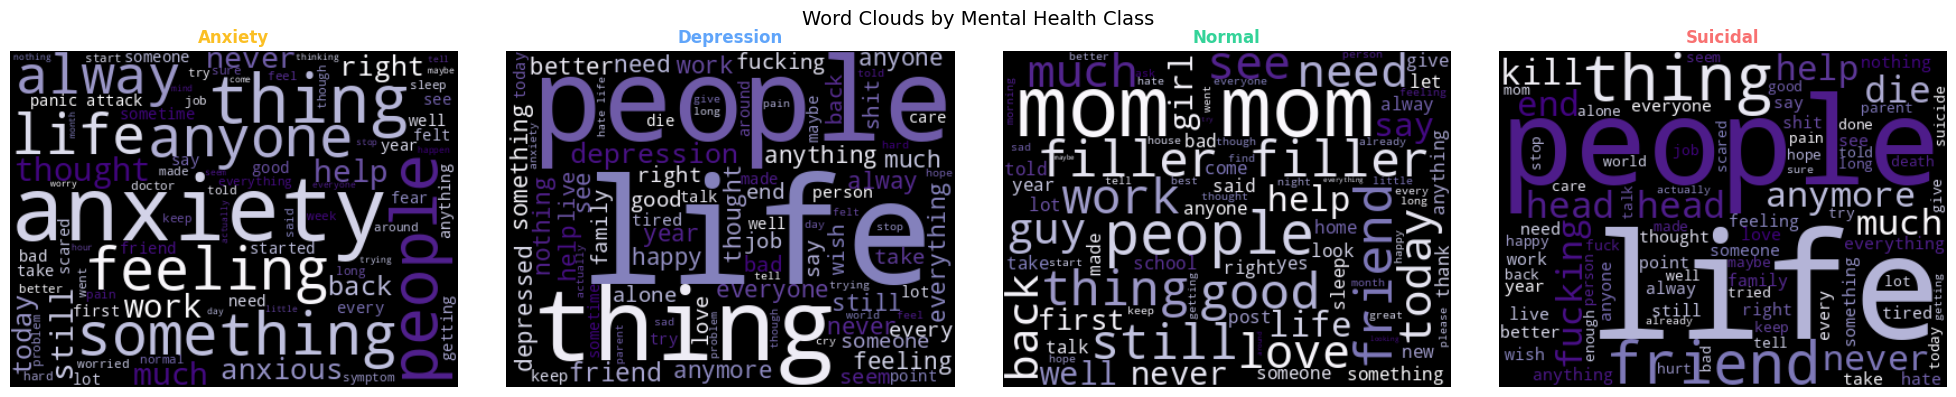

In [11]:
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, (cls, color) in zip(axes, CLASS_COLORS.items()):
        corpus = ' '.join(train_raw[train_raw['status']==cls]['clean_text'])
        if not corpus.strip():
            ax.set_visible(False)
            continue
        wc = WordCloud(width=400, height=300,
                       background_color='black',
                       colormap='Purples',
                       max_words=80).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"{cls}", color=color, fontsize=12, fontweight='bold')
    plt.suptitle("Word Clouds by Mental Health Class", fontsize=14)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("wordcloud not installed — run: !pip install wordcloud")

## Cell 8 — Stage 5 — Feature Engineering

In [12]:
# Split data
X_train_raw = train_raw['clean_text'].values
y_train_raw = train_raw['status'].values
X_test       = test_df['clean_text'].values
y_test        = test_df['status'].values

CLASSES = sorted(list(set(y_train_raw)))
print("Classes:", CLASSES)

# Label encoding — fit on CLASSES only (not all data)
label_encoder = LabelEncoder()
label_encoder.fit(CLASSES)
y_train_enc = label_encoder.transform(y_train_raw)
y_test_enc  = label_encoder.transform(y_test)

# TF-IDF with bigrams
# FIX: sublinear_tf=True reduces impact of very frequent terms
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

# Class weights (handle imbalance — Anxiety has far fewer samples)
cw = compute_class_weight('balanced',
                           classes=np.unique(y_train_enc),
                           y=y_train_enc)
class_weight_dict = {i: w for i, w in enumerate(cw)}
print(f"\nClass weights: {class_weight_dict}")

Classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']
TF-IDF shape: (48522, 15000)
Vocabulary size: 15000

Class weights: {0: np.float64(2.206749135892305), 1: np.float64(0.8369902711653902), 2: np.float64(0.6996481716460953), 3: np.float64(1.0836608897623727)}


## Cell 9 — Stage 6a — Train SVM

In [13]:
import time

print("Training SVM (LinearSVC + CalibratedClassifierCV)...")
t = time.time()

# FIX: LinearSVC doesn't natively output probabilities
# → wrap with CalibratedClassifierCV to get predict_proba
base_svm  = LinearSVC(C=1.0, max_iter=3000,
                       class_weight='balanced', random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_train_tfidf, y_train_enc)

svm_pred = svm_model.predict(X_test_tfidf)
svm_acc  = accuracy_score(y_test_enc, svm_pred)
svm_f1   = f1_score(y_test_enc, svm_pred, average='macro')

print(f"SVM Accuracy : {svm_acc:.4f}")
print(f"SVM F1-macro : {svm_f1:.4f}")
print(f"Time         : {time.time()-t:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test_enc, svm_pred,
                            target_names=label_encoder.classes_))

Training SVM (LinearSVC + CalibratedClassifierCV)...
SVM Accuracy : 0.7480
SVM F1-macro : 0.7456
Time         : 6.8s

Classification Report:
              precision    recall  f1-score   support

     Anxiety       0.93      0.59      0.72       248
  Depression       0.60      0.66      0.63       248
      Normal       0.77      0.92      0.84       248
    Suicidal       0.76      0.83      0.80       248

    accuracy                           0.75       992
   macro avg       0.77      0.75      0.75       992
weighted avg       0.77      0.75      0.75       992



## Cell 10 — Stage 6b — Train Logistic Regression

In [14]:
print("Training Logistic Regression...")
t = time.time()

# FIX: removed deprecated multi_class parameter (sklearn >= 1.5)
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
)
lr_model.fit(X_train_tfidf, y_train_enc)

lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test_enc, lr_pred)
lr_f1   = f1_score(y_test_enc, lr_pred, average='macro')

print(f"LR Accuracy  : {lr_acc:.4f}")
print(f"LR F1-macro  : {lr_f1:.4f}")
print(f"Time         : {time.time()-t:.1f}s")
print("\nClassification Report:")
print(classification_report(y_test_enc, lr_pred,
                            target_names=label_encoder.classes_))

Training Logistic Regression...
LR Accuracy  : 0.7581
LR F1-macro  : 0.7579
Time         : 8.9s

Classification Report:
              precision    recall  f1-score   support

     Anxiety       0.85      0.76      0.80       248
  Depression       0.63      0.62      0.62       248
      Normal       0.82      0.85      0.83       248
    Suicidal       0.74      0.81      0.77       248

    accuracy                           0.76       992
   macro avg       0.76      0.76      0.76       992
weighted avg       0.76      0.76      0.76       992



## Cell 11 — Stage 6c — BERT (GPU required)

In [15]:
# NOTE: BERT fine-tuning requires a GPU runtime.
#       In Colab: Runtime → Change runtime type → T4 GPU
#
# # Uncomment and run if GPU is available:
#
# from transformers import (BertTokenizer, BertForSequenceClassification,
#                            Trainer, TrainingArguments)
# import torch
# from torch.utils.data import Dataset
#
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
#
# class MHDataset(Dataset):
#     def __init__(self, texts, labels, tokenizer, max_len=128):
#         self.enc = tokenizer(list(texts), truncation=True,
#                              padding=True, max_length=max_len,
#                              return_tensors='pt')
#         self.labels = torch.tensor(labels, dtype=torch.long)
#     def __len__(self): return len(self.labels)
#     def __getitem__(self, idx):
#         return {k: v[idx] for k,v in self.enc.items()} | \
#                {'labels': self.labels[idx]}
#
# # Use first 8000 train samples for speed
# N = 8000
# train_ds = MHDataset(X_train_raw[:N], y_train_enc[:N], tokenizer)
# test_ds  = MHDataset(X_test,          y_test_enc,      tokenizer)
#
# bert_model = BertForSequenceClassification.from_pretrained(
#     'bert-base-uncased', num_labels=4)
#
# args = TrainingArguments(
#     output_dir='./bert_mh',
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=32,
#     evaluation_strategy='epoch',
#     save_strategy='epoch',
#     load_best_model_at_end=True,
#     logging_steps=50,
#     report_to='none',
# )
#
# trainer = Trainer(model=bert_model, args=args,
#                   train_dataset=train_ds, eval_dataset=test_ds)
# trainer.train()
# bert_results = trainer.evaluate()
# print(f"BERT Eval: {bert_results}")
print("BERT cell ready — uncomment and run with GPU runtime.")

BERT cell ready — uncomment and run with GPU runtime.


## Cell 12 — Stage 7 — Model Evaluation & Comparison

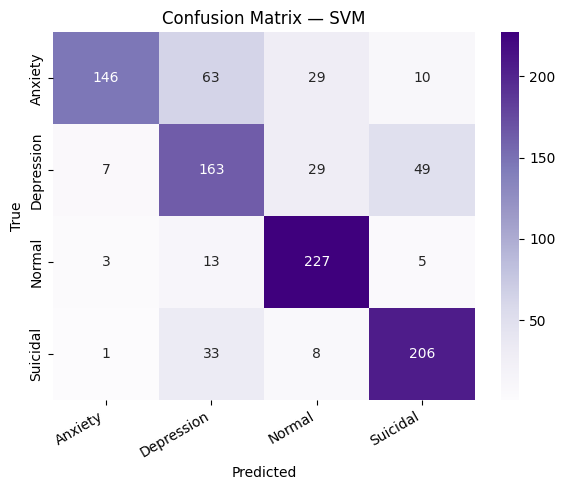

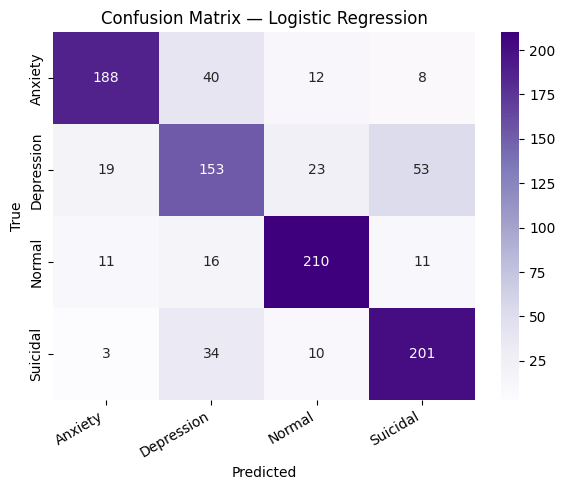

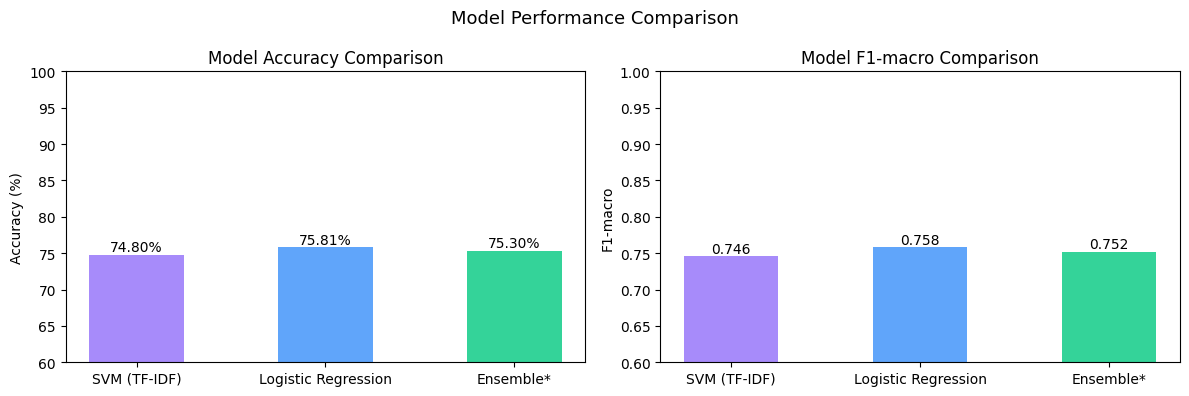


  SVM                 Acc=0.7480  F1=0.7456
  Logistic Regression Acc=0.7581  F1=0.7579
  Ensemble            Acc=0.7530  F1=0.7517


In [16]:
# Confusion matrices
def plot_confusion_matrix(y_true, y_pred, title, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()

plot_confusion_matrix(y_test_enc, svm_pred, "SVM",
                      label_encoder.classes_)
plot_confusion_matrix(y_test_enc, lr_pred,  "Logistic Regression",
                      label_encoder.classes_)

# Accuracy bar chart
model_names = ['SVM (TF-IDF)', 'Logistic Regression', 'Ensemble*']
accs  = [svm_acc, lr_acc, (svm_acc+lr_acc)/2]
f1s   = [svm_f1,  lr_f1,  (svm_f1+lr_f1)/2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(model_names, [a*100 for a in accs],
            color=['#a78bfa','#60a5fa','#34d399'], width=0.5)
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(60, 100)
for i,v in enumerate(accs):
    axes[0].text(i, v*100+0.5, f'{v*100:.2f}%',
                 ha='center', fontsize=10)

axes[1].bar(model_names, f1s,
            color=['#a78bfa','#60a5fa','#34d399'], width=0.5)
axes[1].set_title('Model F1-macro Comparison')
axes[1].set_ylabel('F1-macro')
axes[1].set_ylim(0.6, 1.0)
for i,v in enumerate(f1s):
    axes[1].text(i, v+0.005, f'{v:.3f}',
                 ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=13)
plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"  SVM                 Acc={svm_acc:.4f}  F1={svm_f1:.4f}")
print(f"  Logistic Regression Acc={lr_acc:.4f}  F1={lr_f1:.4f}")
print(f"  Ensemble            Acc={(svm_acc+lr_acc)/2:.4f}  F1={(svm_f1+lr_f1)/2:.4f}")

## Cell 13 — Stage 7 — Sensitivity & Specificity

Sensitivity / Specificity — SVM:
            sensitivity  specificity  precision
Anxiety          0.5887       0.9852     0.9299
Depression       0.6573       0.8535     0.5993
Normal           0.9153       0.9113     0.7747
Suicidal         0.8306       0.9140     0.7630

Sensitivity / Specificity — Logistic Regression:
            sensitivity  specificity  precision
Anxiety          0.7581       0.9556     0.8507
Depression       0.6169       0.8790     0.6296
Normal           0.8468       0.9395     0.8235
Suicidal         0.8105       0.9032     0.7363


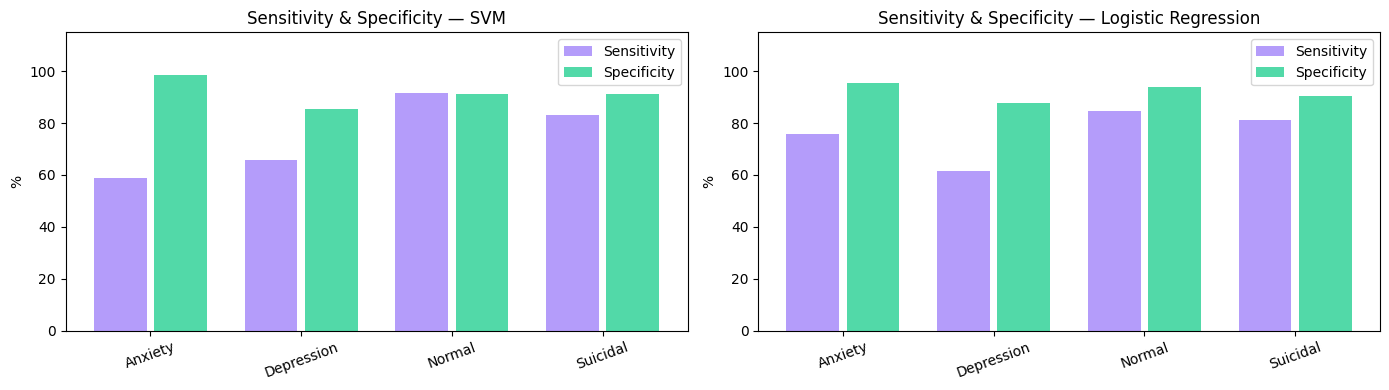

In [17]:
# Critical for clinical screening — high sensitivity = fewer missed cases

def sensitivity_specificity(y_true, y_pred, classes):
    results = {}
    for i, cls in enumerate(classes):
        TP = int(np.sum((y_true==i) & (y_pred==i)))
        TN = int(np.sum((y_true!=i) & (y_pred!=i)))
        FP = int(np.sum((y_true!=i) & (y_pred==i)))
        FN = int(np.sum((y_true==i) & (y_pred!=i)))
        sens = TP / (TP+FN) if (TP+FN) > 0 else 0
        spec = TN / (TN+FP) if (TN+FP) > 0 else 0
        prec = TP / (TP+FP) if (TP+FP) > 0 else 0
        results[cls] = {
            'sensitivity': round(sens, 4),
            'specificity':  round(spec, 4),
            'precision':    round(prec, 4),
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        }
    return results

svm_ss = sensitivity_specificity(y_test_enc, svm_pred,
                                  label_encoder.classes_)
lr_ss  = sensitivity_specificity(y_test_enc, lr_pred,
                                  label_encoder.classes_)

print("Sensitivity / Specificity — SVM:")
ss_df = pd.DataFrame(svm_ss).T
print(ss_df[['sensitivity','specificity','precision']].to_string())

print("\nSensitivity / Specificity — Logistic Regression:")
ss_df_lr = pd.DataFrame(lr_ss).T
print(ss_df_lr[['sensitivity','specificity','precision']].to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (model_name, ss_data) in zip(
        axes, [("SVM", svm_ss), ("Logistic Regression", lr_ss)]):
    classes = list(ss_data.keys())
    x = np.arange(len(classes))
    ax.bar(x-0.2, [ss_data[c]['sensitivity']*100 for c in classes],
           0.35, label='Sensitivity', color='#a78bfa', alpha=0.85)
    ax.bar(x+0.2, [ss_data[c]['specificity']*100 for c in classes],
           0.35, label='Specificity', color='#34d399', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20)
    ax.set_ylim(0, 115); ax.set_ylabel('%')
    ax.set_title(f'Sensitivity & Specificity — {model_name}')
    ax.legend()
plt.tight_layout(); plt.show()

## Cell 14 — Stage 8 — Model Interpretation

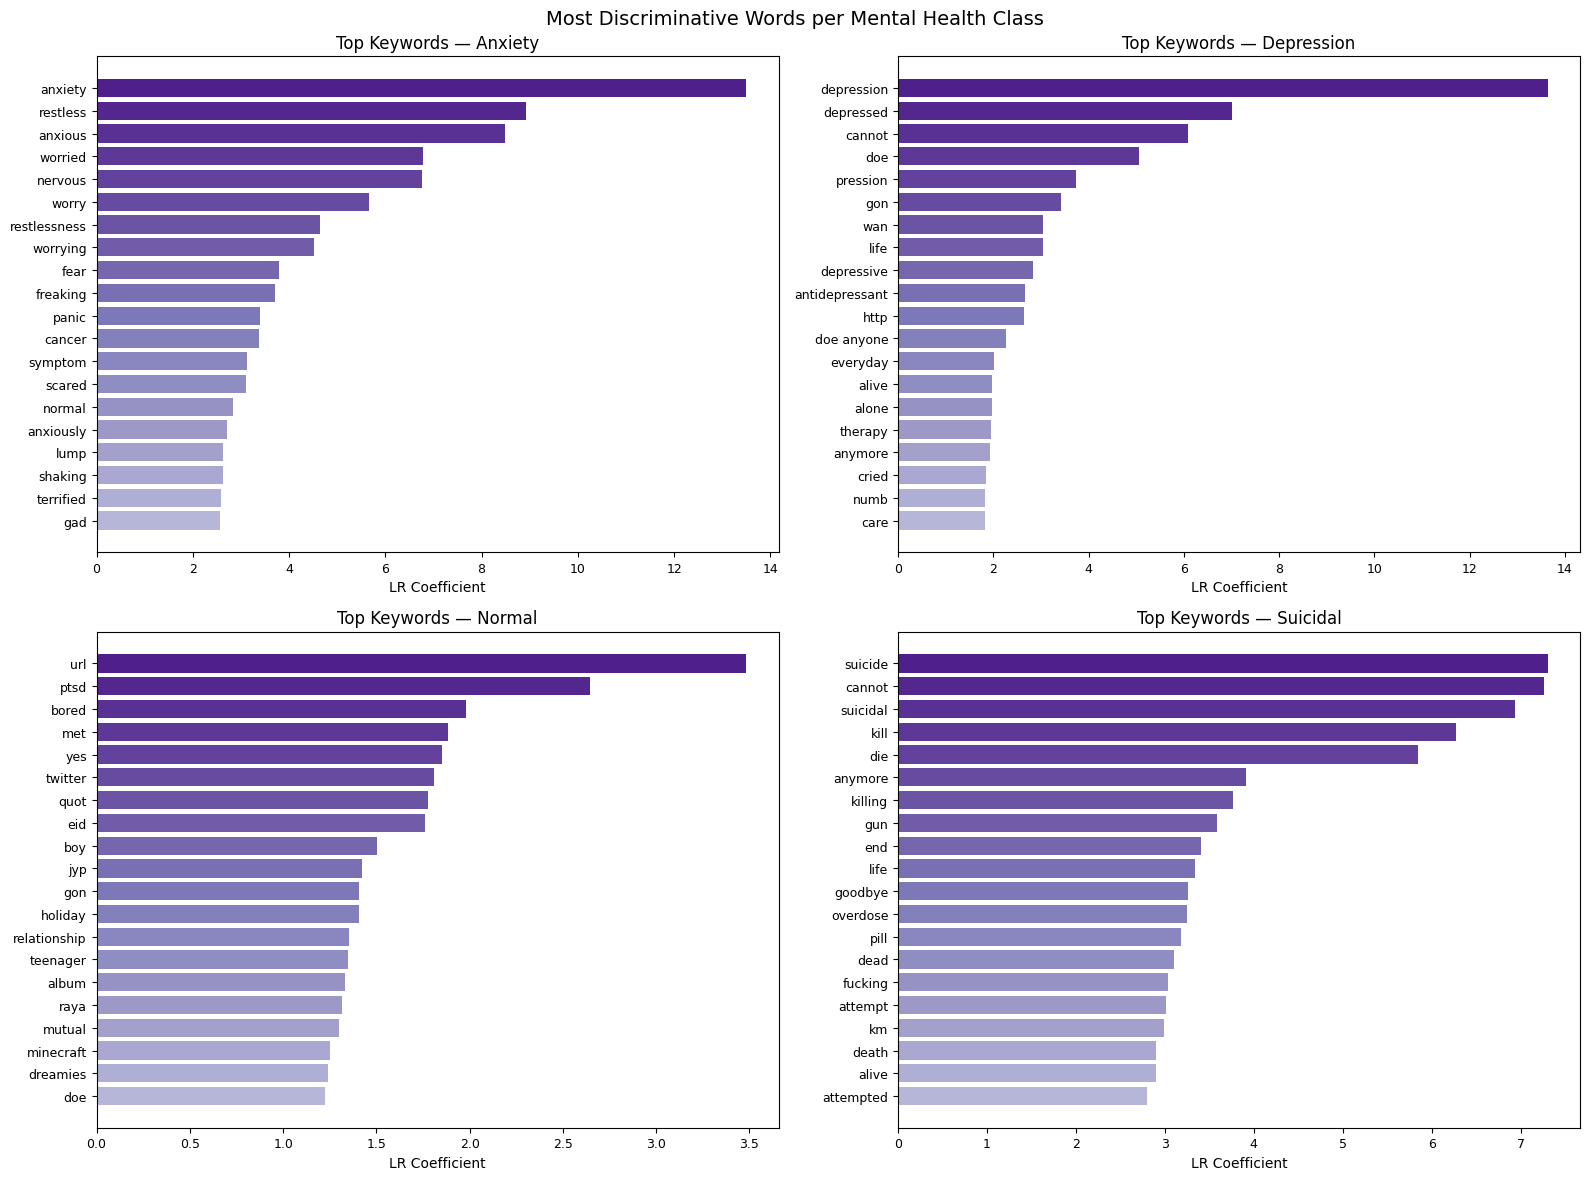

In [18]:
# Top TF-IDF features per class from Logistic Regression coefficients
feature_names = tfidf.get_feature_names_out()
top_features  = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (i, cls) in zip(axes.flatten(),
                         enumerate(label_encoder.classes_)):
    coef    = lr_model.coef_[i]
    top_idx = np.argsort(coef)[-20:][::-1]
    words   = [feature_names[j] for j in top_idx]
    scores  = [coef[j] for j in top_idx]
    top_features[cls] = list(zip(words, [round(float(s),4) for s in scores]))

    colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(words)))
    ax.barh(words[::-1], scores[::-1], color=colors)
    ax.set_title(f'Top Keywords — {cls}', fontsize=12)
    ax.set_xlabel('LR Coefficient')
    ax.tick_params(labelsize=9)

plt.suptitle('Most Discriminative Words per Mental Health Class',
             fontsize=14)
plt.tight_layout(); plt.show()

## Cell 15 — Stage 9 — Save ALL Models

In [19]:
import json

os.makedirs("models", exist_ok=True)

pickle.dump(svm_model,     open("models/svm_model.pkl",     "wb"))
print(" models/svm_model.pkl")

pickle.dump(lr_model,      open("models/lr_model.pkl",      "wb"))
print(" models/lr_model.pkl")

pickle.dump(tfidf,         open("models/tfidf.pkl",         "wb"))
print(" models/tfidf.pkl")

pickle.dump(label_encoder, open("models/label_encoder.pkl", "wb"))
print(" models/label_encoder.pkl")

meta = {
    "classes":       list(label_encoder.classes_),
    "svm_acc":       round(svm_acc, 4),
    "svm_f1":        round(svm_f1,  4),
    "lr_acc":        round(lr_acc,  4),
    "lr_f1":         round(lr_f1,   4),
    "svm_cm":        confusion_matrix(y_test_enc, svm_pred).tolist(),
    "lr_cm":         confusion_matrix(y_test_enc, lr_pred).tolist(),
    "top_features":  {cls: [(w, s) for w, s in feats]
                      for cls, feats in top_features.items()},
    "svm_sens_spec": {cls: {k: v for k,v in d.items()
                            if k not in ('TP','TN','FP','FN')}
                      for cls, d in svm_ss.items()},
    "lr_sens_spec":  {cls: {k: v for k,v in d.items()
                            if k not in ('TP','TN','FP','FN')}
                      for cls, d in lr_ss.items()},
    "train_dist":    train_raw['status'].value_counts().to_dict(),
    "test_dist":     test_df['status'].value_counts().to_dict(),
}
json.dump(meta, open("models/meta.json","w"), indent=2)
print(" models/meta.json")

print("\n🎉 All 5 model files saved!")
print(f"   SVM : {svm_acc*100:.2f}%  F1={svm_f1:.4f}")
print(f"   LR  : {lr_acc*100:.2f}%  F1={lr_f1:.4f}")

 models/svm_model.pkl
 models/lr_model.pkl
 models/tfidf.pkl
 models/label_encoder.pkl
 models/meta.json

🎉 All 5 model files saved!
   SVM : 74.80%  F1=0.7456
   LR  : 75.81%  F1=0.7579


## Cell 16 — Stage 9 — Write app.py & requirements.txt

In [20]:
# Writes the Streamlit app directly to /content/app.py

APP_CODE = open("app.py").read() if os.path.exists("app.py") else ""
# (app.py is provided separately in the GitHub repo)

REQUIREMENTS = """streamlit>=1.32.0
numpy>=1.24.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
joblib>=1.3.0
"""
with open("requirements.txt","w") as f:
    f.write(REQUIREMENTS)
print(" requirements.txt written")

 requirements.txt written


In [21]:
APP_PY_CODE = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import json
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load NLTK data if not already downloaded (for deployment)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# --- Text Cleaning Function (from notebook) ---
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

MENTAL_HEALTH_STOPWORDS = {
    'feel', 'like', 'im', 'ive', 'dont', 'cant', 'just',
    'get', 'really', 'know', 'think', 'time', 'one', 'day',
    'want', 'make', 'go', 'going', 'got', 'even', 'way',
}

def clean_text(text):
    """Full NLP cleaning pipeline matching production preprocessing."""
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)               # mentions/hashtags
    text = re.sub(r'\d+', '', text)                     # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep letters only
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS
              and t not in MENTAL_HEALTH_STOPWORDS
              and len(t) > 2]
    return ' '.join(tokens)

# --- Load Models and Artifacts ---
@st.cache_resource
def load_models():
    with open("models/svm_model.pkl", "rb") as f:
        svm_model = pickle.load(f)
    with open("models/lr_model.pkl", "rb") as f:
        lr_model = pickle.load(f)
    with open("models/tfidf.pkl", "rb") as f:
        tfidf = pickle.load(f)
    with open("models/label_encoder.pkl", "rb") as f:
        label_encoder = pickle.load(f)
    with open("models/meta.json", "r") as f:
        meta = json.load(f)
    return svm_model, lr_model, tfidf, label_encoder, meta

svm_model, lr_model, tfidf, label_encoder, meta = load_models()
CLASSES = meta['classes']

# --- Streamlit App ---
st.set_page_config(
    page_title="Mental Health Classifier",
    page_icon="🧠",
    layout="centered",
    initial_sidebar_state="collapsed",
)

st.title("🧠 Mental Health Status Classifier")
st.markdown("Classify social media text into 'Anxiety', 'Depression', 'Suicidal', or 'Normal'.")

user_input = st.text_area("Enter your text here:", height=150)

if st.button("Classify"):
    if user_input.strip() == "":
        st.warning("Please enter some text to classify.")
    else:
        st.info("Classifying...")

        # Preprocess text
        clean_text_input = clean_text(user_input)
        if clean_text_input.strip() == "":
            st.warning("The input text became empty after cleaning. Please try different text.")
        else:
            # TF-IDF transform
            text_tfidf = tfidf.transform([clean_text_input])

            # Predict with SVM
            svm_pred_encoded = svm_model.predict(text_tfidf)[0]
            svm_pred_proba   = svm_model.predict_proba(text_tfidf)[0]
            svm_pred_class   = label_encoder.inverse_transform([svm_pred_encoded])[0]

            # Predict with Logistic Regression
            lr_pred_encoded  = lr_model.predict(text_tfidf)[0]
            lr_pred_proba    = lr_model.predict_proba(text_tfidf)[0]
            lr_pred_class    = label_encoder.inverse_transform([lr_pred_encoded])[0]

            st.subheader("Classification Results")

            col1, col2 = st.columns(2)

            with col1:
                st.markdown("#### SVM Prediction")
                st.success(f"Predicted Class: **{svm_pred_class}**")
                st.write("Probabilities:")
                svm_proba_df = pd.DataFrame({
                    'Class': CLASSES,
                    'Probability': svm_pred_proba
                }).set_index('Class')
                st.bar_chart(svm_proba_df)

            with col2:
                st.markdown("#### Logistic Regression Prediction")
                st.success(f"Predicted Class: **{lr_pred_class}**")
                st.write("Probabilities:")
                lr_proba_df = pd.DataFrame({
                    'Class': CLASSES,
                    'Probability': lr_pred_proba
                }).set_index('Class')
                st.bar_chart(lr_proba_df)

            st.markdown("**Note:** SVM and Logistic Regression models might give slightly different results. For critical applications, consider ensemble methods or expert review.")

st.markdown("""
---
This app uses TF-IDF features with SVM and Logistic Regression models to classify text.
Models were trained on a dataset of social media posts.
""")
'''

with open("app.py", "w") as f:
    f.write(APP_PY_CODE)
print(" app.py written")

 app.py written


## Cell 17 — Stage 9 — Launch Streamlit in Colab (clickable URL)

In [22]:
import subprocess, sys, time, re
import os # Needed for os.setsid
import urllib.request

print("📦 Installing tunnel packages...")
subprocess.run([sys.executable,"-m","pip","install","pyngrok","streamlit","-q"], check=True)

# Kill old processes
subprocess.run(["pkill","-f","streamlit"], capture_output=True)
time.sleep(2) # Give a bit more time for pkill

# Start Streamlit
# Using preexec_fn=os.setsid to ensure it runs in a new session (more robust background)
streamlit_proc = subprocess.Popen(
    [sys.executable,"-m","streamlit","run","app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false",
     "--server.enableXsrfProtection=false",
     "--browser.gatherUsageStats=false"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, preexec_fn=os.setsid
)

# Wait for server to start
print("⏳ Starting Streamlit", end="")
max_wait_time = 60 # Increase max wait time to 60 seconds
for _ in range(max_wait_time // 2): # Check every 2 seconds
    time.sleep(2)
    print(".", end="", flush=True)

    # Check if Streamlit process is still alive
    if streamlit_proc.poll() is not None:
        print("\n Streamlit process terminated prematurely!")
        stderr_output = streamlit_proc.stderr.read().decode('utf-8')
        if stderr_output:
            print("Streamlit stderr:")
            print(stderr_output)
        break

    try:
        urllib.request.urlopen("http://localhost:8501", timeout=3) # Increased timeout
        print(" ready!")
        break
    except Exception:
        continue
else:
    print("\n Streamlit failed to become ready within the allotted time.")
    stderr_output = streamlit_proc.stderr.read().decode('utf-8')
    if stderr_output:
        print("Streamlit stderr:")
        print(stderr_output)

# Create ngrok tunnel
from pyngrok import ngrok, conf

# ─────────────────────────────────────────────────────────────
# GET YOUR FREE TOKEN (takes 2 minutes):
#   1. Go to https://dashboard.ngrok.com/signup
#   2. Sign up free
#   3. Copy token from https://dashboard.ngrok.com/get-started/your-authtoken
#   4. Paste it below replacing YOUR_NGROK_TOKEN_HERE
# ─────────────────────────────────────────────────────────────
NGROK_TOKEN = "3CbpPHUbhmRVBfihdqBxQeQKecC_6Ywhh54t8LKUd7abcDTtT"

from pyngrok import ngrok, conf
conf.get_default().auth_token = NGROK_TOKEN
ngrok.kill()
time.sleep(1)

try:
    public_url = ngrok.connect(8501).public_url
    if not public_url.startswith("https"):
        public_url = public_url.replace("http://","https://")

    from IPython.display import display, HTML
    display(HTML(f"""
<div style=\"background:#0b0f1a;border:2px solid #a78bfa;border-radius:14px;
            padding:22px 30px;margin:14px 0;font-family:monospace;\">
  <div style=\"color:#8892a4;font-size:12px;letter-spacing:3px;
              text-transform:uppercase;margin-bottom:10px;\">
    🧠 Mental Health Classifier — Live URL
  </div>
  <a href=\"{public_url}\" target=\"_blank\"
     style=\"color:#a78bfa;font-size:26px;font-weight:bold;text-decoration:none;\">
     {public_url}
  </a>
  <div style=\"color:#34d399;font-size:13px;margin-top:12px;\">
     Your app is live! Click the link above to open it in a new tab.
  </div>
  <div style=\"color:#555f7a;font-size:11px;margin-top:8px;\">
    This URL stays active while your Colab session runs.<br>
    For a permanent URL → deploy to <b>share.streamlit.io</b>
  </div>
</div>
"""))
    print(f"\n Live at: {public_url}")

except Exception as e:
    print(f"\n ngrok error: {e}")
    print("   → Make sure you pasted a valid ngrok token above.")
    print("   → Get one free at: https://dashboard.ngrok.com/signup")

📦 Installing tunnel packages...
⏳ Starting Streamlit.... ready!



 Live at: https://wheat-amiable-impotent.ngrok-free.dev


## Cell 18 — Stage 10 — Zip & Download for GitHub

In [23]:
import shutil
from google.colab import files

shutil.make_archive("mental_health_deploy", "zip", ".", "models")
print(" mental_health_deploy.zip created")

for fname in ["app.py", "requirements.txt", "mental_health_deploy.zip"]:
    if os.path.exists(fname):
        files.download(fname)
        print(f"⬇  {fname} downloading...")

print("""
══════════════════════════════════════════════════════════════
 DEPLOYMENT STEPS (permanent Streamlit URL):
══════════════════════════════════════════════════════════════
 1. Create GitHub repo: mental-health-classifier
 2. Upload: app.py  requirements.txt  README.md
 3. Unzip mental_health_deploy.zip → upload models/ folder
 4. Go to https://share.streamlit.io
    → New app → select repo → app.py → Deploy
 5. Get permanent live URL in ~2 minutes
══════════════════════════════════════════════════════════════
""")

 mental_health_deploy.zip created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  app.py downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  requirements.txt downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  mental_health_deploy.zip downloading...

══════════════════════════════════════════════════════════════
 DEPLOYMENT STEPS (permanent Streamlit URL):
══════════════════════════════════════════════════════════════
 1. Create GitHub repo: mental-health-classifier
 2. Upload: app.py  requirements.txt  README.md
 3. Unzip mental_health_deploy.zip → upload models/ folder
 4. Go to https://share.streamlit.io
    → New app → select repo → app.py → Deploy
 5. Get permanent live URL in ~2 minutes 
══════════════════════════════════════════════════════════════

